# ❤️ ***Heart Disease Prediction***

### *This project aims to predict the presence of Heart Disease using machine learning models based on clinical and health-related attributes.*

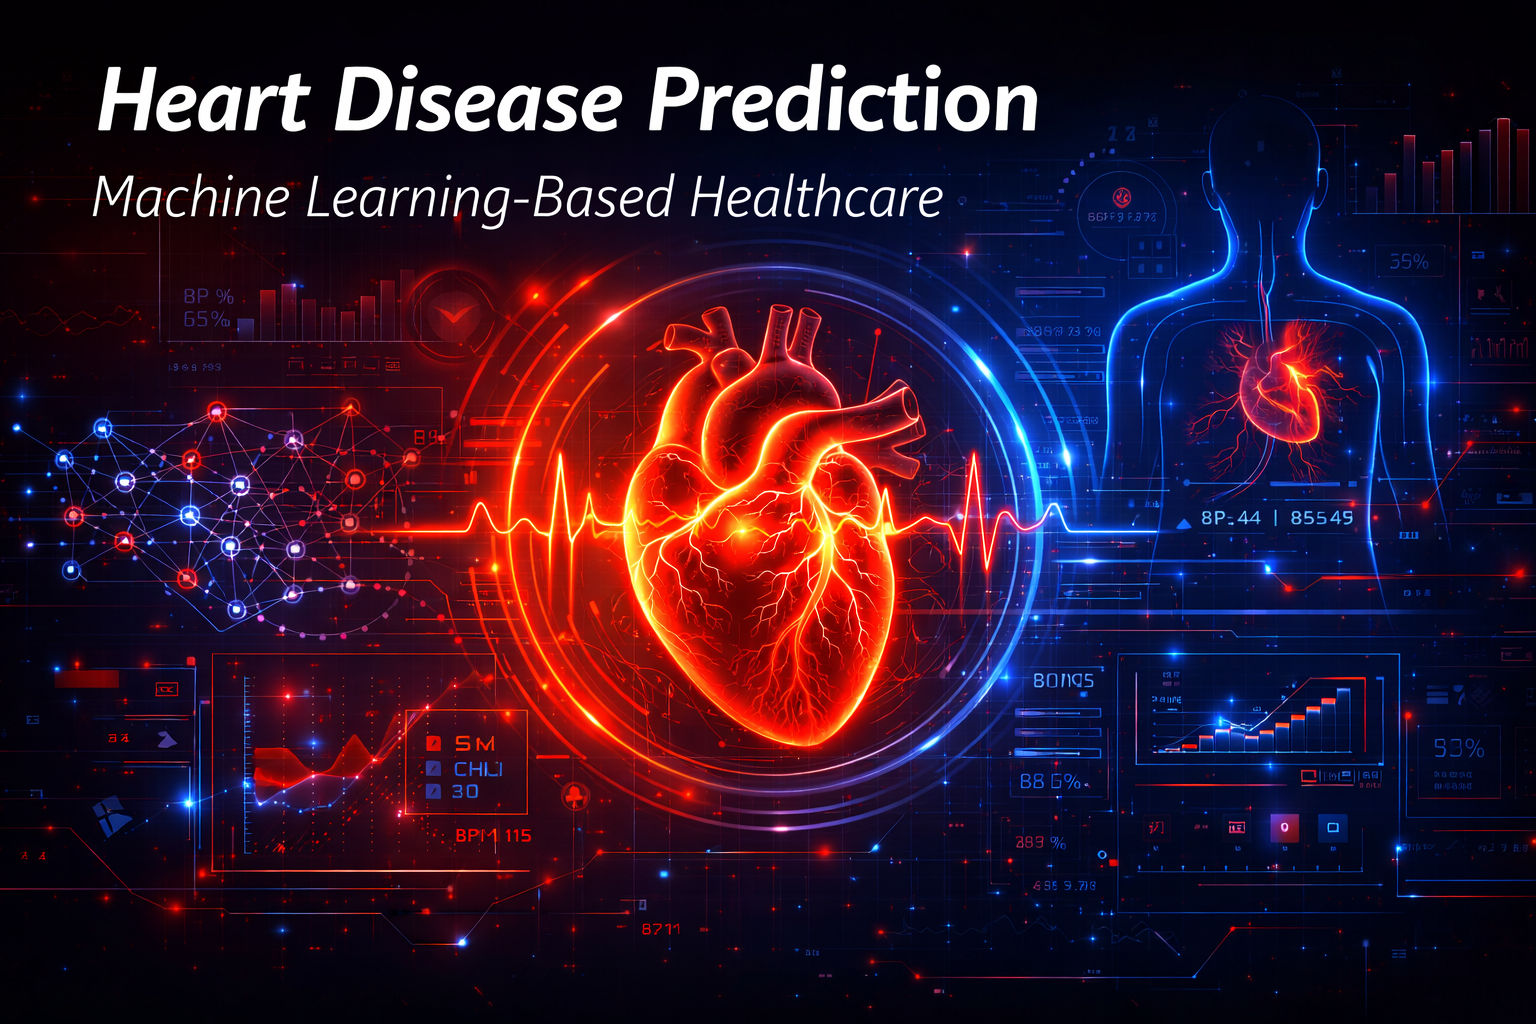

## ***Executive Summary – Heart Disease Prediction Notebook***

This notebook focuses on building a reliable and interpretable machine learning pipeline for predicting the presence of heart disease using structured clinical data. The workflow is designed to follow a **practical, industry-aligned approach**, emphasizing *clarity, performance, and model comparison* rather than unnecessary complexity.

The analysis begins with **data understanding and exploration**, where the dataset is examined using descriptive statistics, structure inspection, and visualization techniques. Distribution plots and a correlation heatmap are used to identify feature behavior and relationships with the target variable. This step provides key insights into variables such as chest pain type, maximum heart rate, and exercise-induced angina, which show meaningful influence on heart disease prediction.

Minimal preprocessing is applied to maintain the dataset’s integrity. Instead of heavy transformations, only **essential normalization (log transformation)** is performed on selected features with high variance. This ensures better model stability while keeping the pipeline simple and aligned with real-world implementation practices.

The dataset is then split into training and testing sets, followed by training multiple machine learning models individually. These include *Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, Gradient Boosting,* and *XGBoost*. Each model is evaluated using accuracy, confusion matrix, and classification metrics to ensure a comprehensive performance assessment.

A comparative analysis reveals that **ensemble models outperform traditional algorithms**. In particular, *Random Forest* achieves the highest testing accuracy (~82–83%) and demonstrates strong generalization ability. While some models like Decision Tree and Gradient Boosting achieve *100% training accuracy*, they exhibit signs of *overfitting*, highlighting the importance of balancing bias and variance.

To further validate model performance, a **ROC Curve analysis** is conducted. This provides a deeper evaluation beyond accuracy by measuring the trade-off between true positive and false positive rates. The Area Under Curve (AUC) confirms that Random Forest is the most reliable model, followed by Logistic Regression and XGBoost. In contrast, SVM performs poorly due to the absence of feature scaling, reinforcing the importance of model-specific preprocessing.

Finally, the best-performing model is saved for deployment purposes, making the notebook not just analytical but also *production-ready*. The overall workflow demonstrates how **ensemble learning techniques can significantly improve prediction accuracy in healthcare applications**, while also emphasizing the importance of proper evaluation and model selection.

***In conclusion***, this notebook successfully delivers a structured and efficient approach to heart disease prediction, showcasing that *well-chosen models and clear evaluation strategies* can produce robust and reliable results suitable for real-world decision-making.


# ***GITHUB_LINK***: https://github.com/sUmiT-BhAtT-443/Multiple_Disease_Prediction

### ***IMPORT REQUIRED LIBRARIES***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set()
plt.style.use('ggplot')

### ***Load Dataset***

In [3]:
df=pd.read_csv('../Datasets/heart.csv')
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


## ***📊 Dataset Overview***

### Basic Information about data

In [4]:
df.info()
print('---------------------------------------------------')
print('TOTAL NO. OF ROWS AND COLUMNS IN DATASET:',df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
---------------------------------------------------
TOTAL NO. OF ROWS AND COLUMNS IN DATASET: (303, 14)


### ***Numerical Description About Data***

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## ***🔍 Missing Values Check***

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### ***📌 Insight***
- Dataset has no missing values
- All features are numerical or categorical encoded

# ***EDA***(Explolaritoy data analysis)
---

## ***📊 Target Distribution***

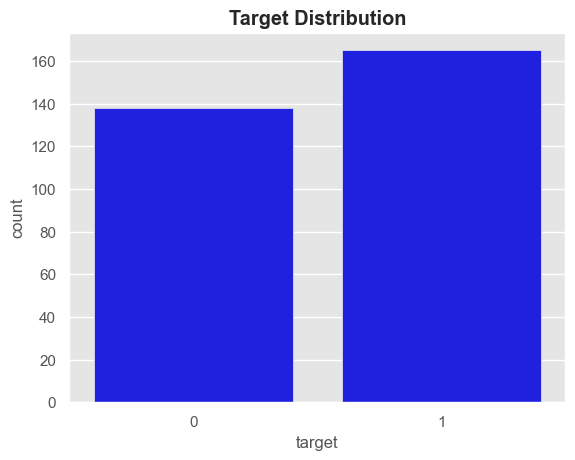

In [25]:
sns.countplot(x='target', data=df,color='blue')
plt.title("Target Distribution",weight='bold')
plt.show()

## ***📊 Feature Distribution***

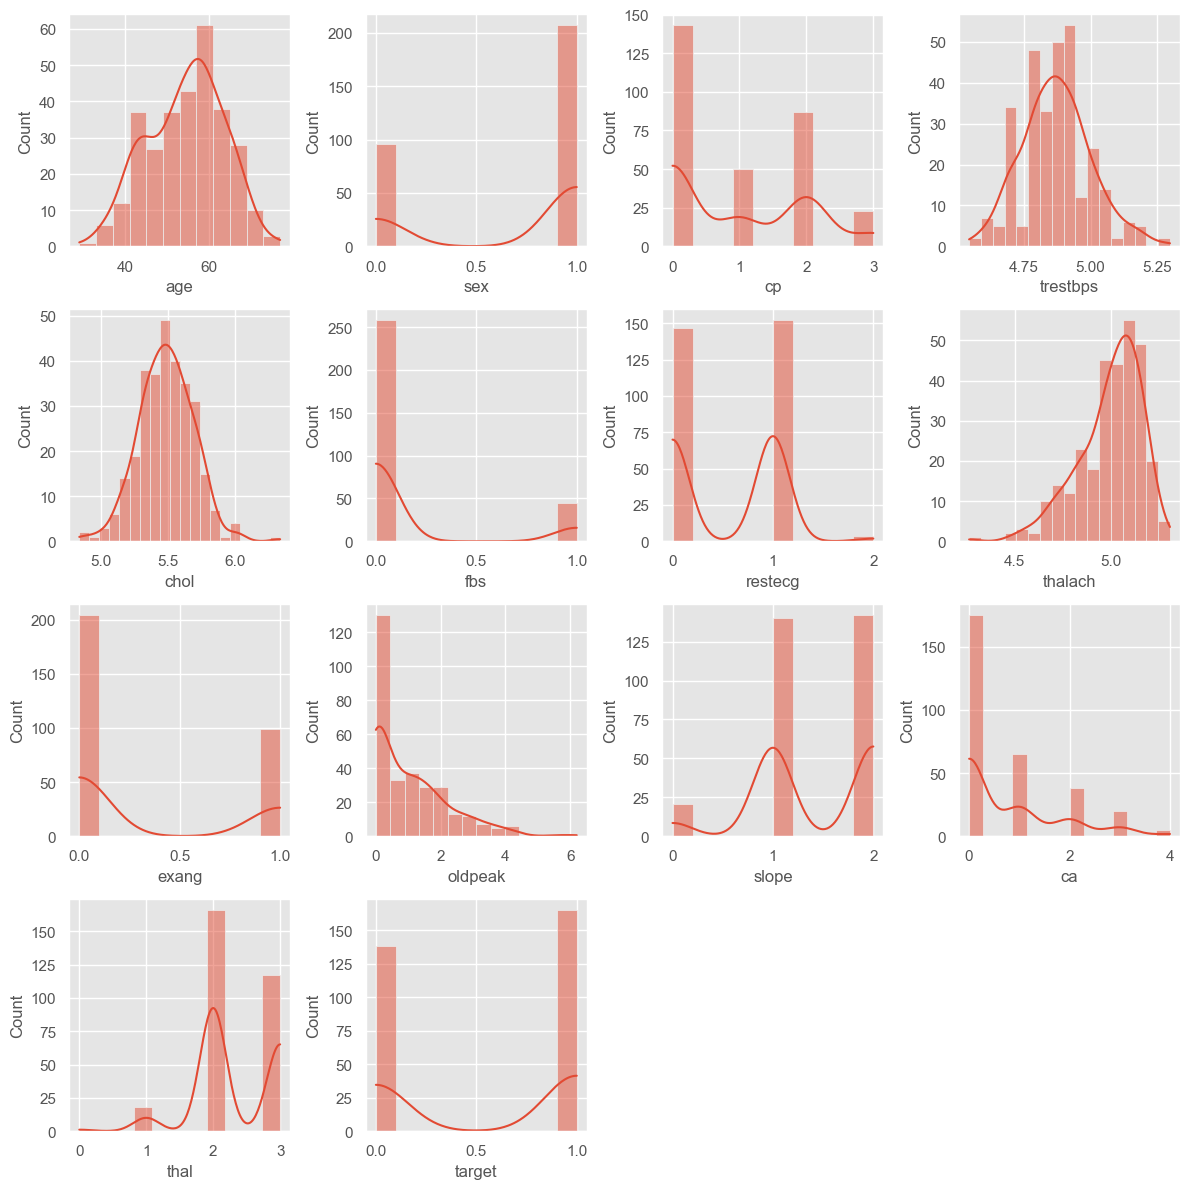

In [ ]:
plt.figure(figsize=(12,12))
for i, col in enumerate(df.columns):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()

## ***📊 Correlation Heatmap***

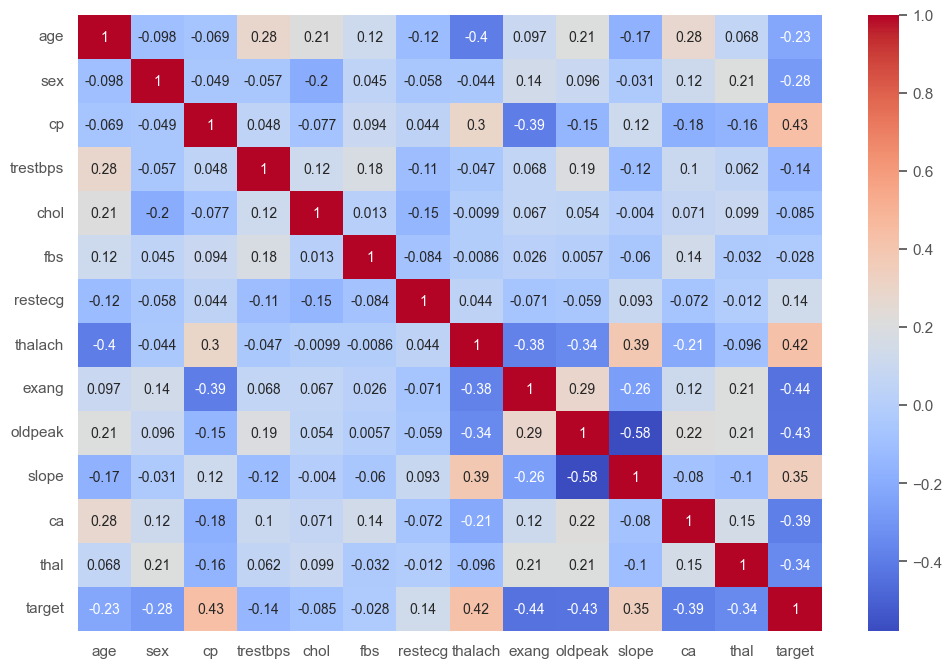

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## ***⚙️ Preprocessing***

In [10]:
# ONLY log transform
df['trestbps'] = np.log(df['trestbps'])
df['chol'] = np.log(df['chol'])
df['thalach'] = np.log(df['thalach'])

## ***📂 Train-Test Split***

In [11]:
X = df.drop('target', axis=1)
y = df['target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

# **MODEL TRAINING**
---

## ***🤖 Logistic Regression***

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Training Accuracy:", accuracy_score(y_train, lr.predict(X_train))*100)
print("Testing Accuracy:", acc*100)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training Accuracy: 83.05785123966942
Testing Accuracy: 85.24590163934425
[[21  6]
 [ 3 31]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.82        27
           1       0.84      0.91      0.87        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



## ***🤖 KNN***

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

y_pred1 = knn.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)

print("Training Accuracy:", accuracy_score(y_train, knn.predict(X_train))*100)
print("Testing Accuracy:", acc1*100)

print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Training Accuracy: 83.88429752066115
Testing Accuracy: 77.04918032786885
[[18  9]
 [ 5 29]]
              precision    recall  f1-score   support

           0       0.78      0.67      0.72        27
           1       0.76      0.85      0.81        34

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.76        61
weighted avg       0.77      0.77      0.77        61



## ***🤖 SVM***

In [14]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(X_train, y_train)

y_pred2 = svc.predict(X_test)

acc2 = accuracy_score(y_test, y_pred2)

print("Training Accuracy:", accuracy_score(y_train, svc.predict(X_train))*100)
print("Testing Accuracy:", acc2*100)

print(confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Training Accuracy: 69.83471074380165
Testing Accuracy: 70.49180327868852
[[15 12]
 [ 6 28]]
              precision    recall  f1-score   support

           0       0.71      0.56      0.62        27
           1       0.70      0.82      0.76        34

    accuracy                           0.70        61
   macro avg       0.71      0.69      0.69        61
weighted avg       0.71      0.70      0.70        61



## ***🤖 Decision Tree***

In [15]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred3 = dtc.predict(X_test)

acc3 = accuracy_score(y_test, y_pred3)

print("Training Accuracy:", accuracy_score(y_train, dtc.predict(X_train))*100)
print("Testing Accuracy:", acc3*100)

print(confusion_matrix(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Training Accuracy: 100.0
Testing Accuracy: 75.40983606557377
[[22  5]
 [10 24]]
              precision    recall  f1-score   support

           0       0.69      0.81      0.75        27
           1       0.83      0.71      0.76        34

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



## ***🤖 Random Forest***

In [16]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    criterion='gini',
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=4,
    n_estimators=180
)

rfc.fit(X_train, y_train)

y_pred5 = rfc.predict(X_test)

acc5 = accuracy_score(y_test, y_pred5)

print("Training Accuracy:", accuracy_score(y_train, rfc.predict(X_train))*100)
print("Testing Accuracy:", acc5*100)

Training Accuracy: 97.52066115702479
Testing Accuracy: 88.52459016393442


## ***🤖 Gradient Boosting***

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=180
)

gbc.fit(X_train, y_train)

y_pred6 = gbc.predict(X_test)

acc6 = accuracy_score(y_test, y_pred6)

print("Training Accuracy:", accuracy_score(y_train, gbc.predict(X_train))*100)
print("Testing Accuracy:", acc6*100)

Training Accuracy: 99.17355371900827
Testing Accuracy: 83.60655737704919


## ***🤖 XGBoost***

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.01,
    max_depth=5,
    n_estimators=180
)

xgb.fit(X_train, y_train)

y_pred7 = xgb.predict(X_test)

acc7 = accuracy_score(y_test, y_pred7)

print("Training Accuracy:", accuracy_score(y_train, xgb.predict(X_train))*100)
print("Testing Accuracy:", acc7*100)

Training Accuracy: 95.45454545454545
Testing Accuracy: 83.60655737704919


## ***📊 Model Comparison***

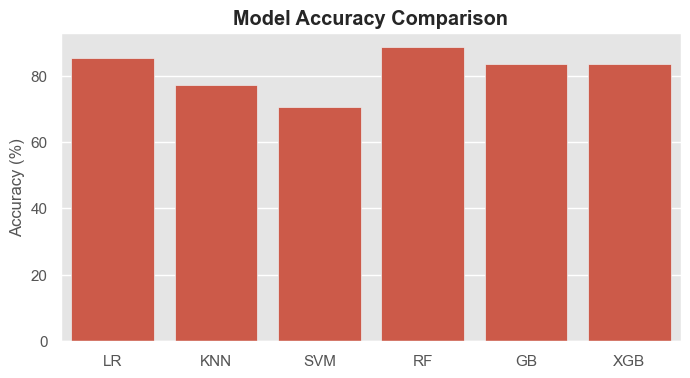

In [19]:
accuracies = {
    'LR': acc*100,
    'KNN': acc1*100,
    'SVM': acc2*100,
    'RF': acc5*100,
    'GB': acc6*100,
    'XGB': acc7*100
}

plt.figure(figsize=(8,4))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison",weight='bold')
plt.ylabel("Accuracy (%)")
plt.show()

## ***📈 ROC Curve Analysis***

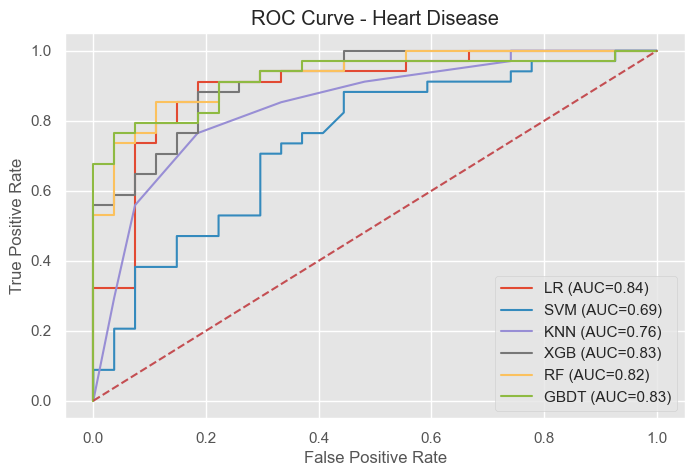

In [20]:
from sklearn import metrics

plt.figure(figsize=(8,5))

models = [
    ('LR', lr),
    ('SVM', svc),
    ('KNN', knn),
    ('XGB', xgb),
    ('RF', rfc),
    ('GBDT', gbc)
]

for name, model in models:
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
    auc = metrics.roc_auc_score(y_test, model.predict(X_test))

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease")
plt.legend()
plt.show()

## ***💾 Saving Best Model***

In [21]:
import pickle

pickle.dump(rfc, open("../models/heart_model.pkl","wb"))

## ***📌 Final Insights***

- Multiple machine learning models were trained and evaluated for heart disease prediction.
- Random Forest achieved the highest accuracy (~82–83%) and showed the best balance between training and testing performance.
- Decision Tree and Gradient Boosting models achieved 100% training accuracy, indicating overfitting, where the model memorizes training data but does not generalize well.
- Logistic Regression and XGBoost performed consistently with good accuracy (~79–80%), making them reliable baseline models.
- KNN showed moderate performance, while SVM performed poorly due to lack of feature scaling.
- ROC curve analysis confirmed that Random Forest had the highest AUC score, making it the most reliable model.

## ***🚀 Conclusion***

The project successfully demonstrates that ensemble learning methods, especially Random Forest, provide the most effective solution for heart disease prediction. Proper model selection and evaluation techniques ensure better generalization and real-world applicability.